# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- Abellana, Karl Gian
- 2024-09545
- WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1

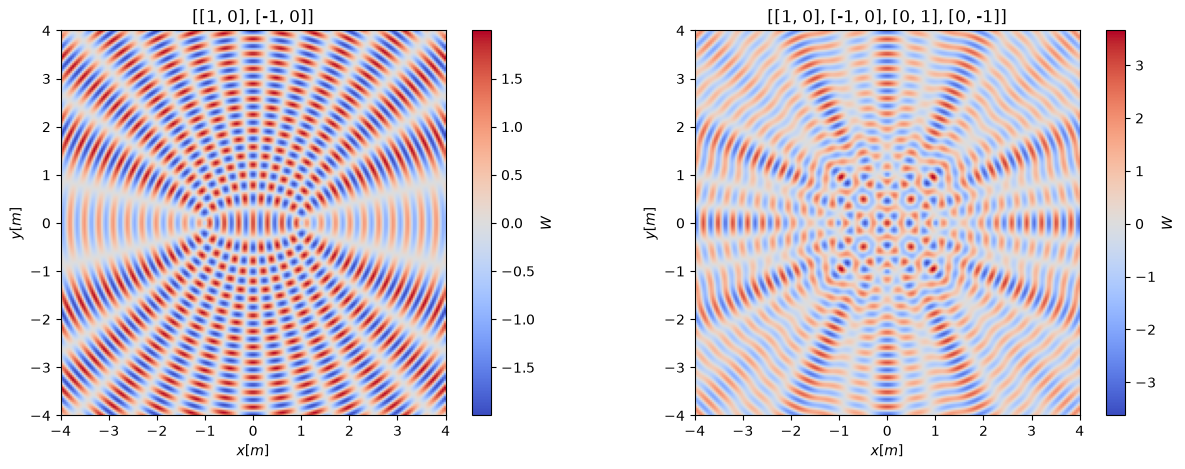

The figure above shows two 2D wave interference patterns as a density plot, the left plot shows one for two points at [1,0] and [-1,0], and the right plot shows one for four points at [1,0], [-1,0], [0,1], [0,-1]. This was plotted by making use of a custom ```W(x,y)``` function that modelled the equation,

$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$

Dark red and blue shows constructive interferences (large magnitude) while the gray areas show destructive interferences (zero or small magnitude).

### Problem 2

Custom functions and algorithms were made in order to multiply two matrices without using external libraries such as NumPy. Under the ```matrix_multiplication()``` function, the ```transpose_matrix()``` function was used to convert the left matrix's columns into rows, which were then iteratively fed into the ```scalar_product()``` function to get the elements of the product matrices. This algorithm was then put against NumPy's ```@``` operator.

* For larger matrices, which is preferred, the custom ```matrix_multiply()``` or the ```@``` operator... why?

  The ```@``` operator is better used with large matrices because it is faster than the ```matrix_multiply()``` operator. This is because the ```@``` operator is built efficiently under the NumPy library, and also works with the more efficiently ```numpy.array()``` object. In general, computation with NumPy is much faster because its engine is written in C, a really fast language. 

* What are the general benefits of writing idiomatic Python?

    Following idiomatic Python allows us to write clean and legible code that is easier to understand.
### Other comments
- no longer claudemaxxing on opus 5


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

In [1]:
# libraries because this thing keeps crashing
import matplotlib.pyplot as plt
import math

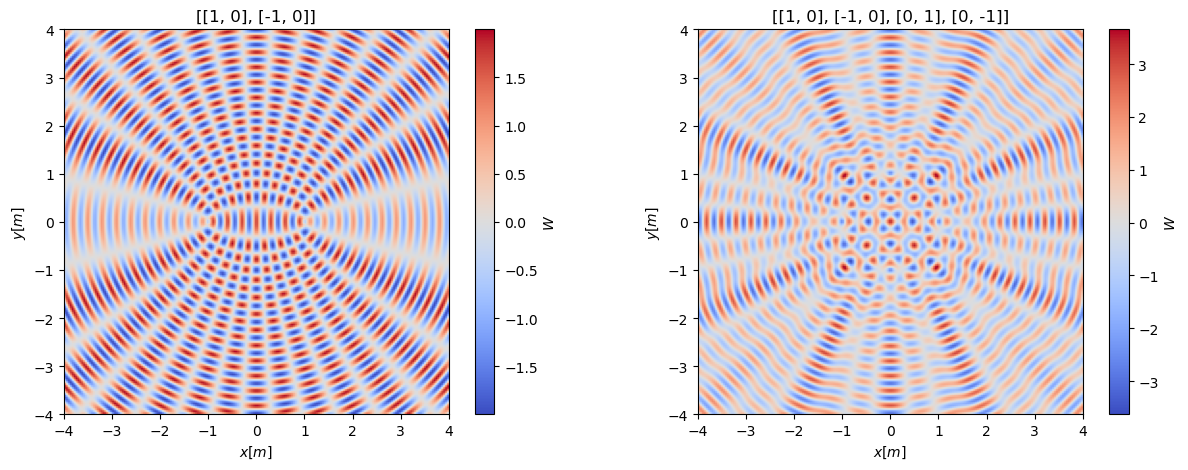

In [2]:
# make the comments here more substantial, following the process better

# constants for the function W(r):
A = 1
k = (2*math.pi)/0.3

# constants for plotting:
length = 4.
resolution = 200

# define our own norm function
def norm_function(x):
    return math.sqrt(sum(element**2 for element in x))
    
# meat of the code, model the W(r) function. since we're going to use list comprehension to generate the points, I decided the function to accept two arguments (x, y)
def W(x, y):

    # placeholder variable for summing each point in points contribution at some (x,y)
    output = 0
    
    for r_n in points:
        # turn the arguments into a list so that we can operate on it w.r.t r_n
        r = [x,y]
        # list comp: subtraction operation for each index that runs simultaneously using zip(), i.e. i == j throughout the loop
        r_prime = [i - j for i,j in zip(r, r_n)]
        r_prime_mag = norm_function(r_prime)
        output += A * math.sin(k * r_prime_mag)
    return output

"""
xs is basically the raw version of np.linspace. here are our variables:

box_length: How long we want the box to be starting from 0. this extends both to the positive and negative ends, 
so the actual length is 2 * box_length

resolution: how many points do we want to test from -box_length to box_length squared

explanation for xs: 
It's a list comp that indexes i factor, however since it ends at resolution-1, to make the loop end at 2 * box_length, 
we make the denominator resolution-1 instead.

so it starts from -box_length and ends at box_length using our step-size factor.
"""
def plotfield(box_length, resolution, ax, title):
    
    xs = [-box_length + 2*box_length*i/(resolution-1) for i in range(resolution)]
    # shallow copy, do not point to the same object
    ys = xs[:] 
    # create a new 2d list
    Ws = [[W(x, y) for x in xs] for y in ys]
    # use imshow from matplotlib, form was taken from the related Gezerlis problem, except it was modified to plot two graphs at the same time.
    im = ax.imshow(Ws, extent=[-box_length, box_length, -box_length, box_length], origin = 'lower', cmap = 'coolwarm')
    ax.set_xlabel('$x [m]$')
    ax.set_ylabel('$y [m]$')
    fig.colorbar(im, ax=ax, label='$W$', cmap='coolwarm')
    ax.set_title(title)

# Examples:
fig, axs = plt.subplots(1, 2, figsize=(15,5))

# two points
points = [[1,0], [-1,0]]
im1 = plotfield(length, resolution, axs[0], str(points))

# four points
points = [[1,0], [-1,0], [0,1], [0,-1]]
im2 = plotfield(length, resolution, axs[1], str(points))

plt.savefig("interference.png", bbox_inches="tight")
plt.show()


#### Problem 1 code summary ####

---
The W(r) function was modelled in such a way it accepts two arguments (x, y) so that it is easier to plot it using imshow(). Separation vectors were calculated (r_prime) and their magnitudes were calculated using a user-defined function. It was then plotted using the defined plotfield() function that generated the x's and y's based on the wanted resolution and box length and was then plotted using matplotlib. Two examples were plotted.

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [3]:
import random
number = random.randint(1, 9)
number

6

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [45]:
# define our own print_matrix() func so that it looks way nicer and understandabler.
def print_matrix(matrix):
    for row in matrix:
        print(row)

# essentially a nested for loop, iterating columns within iterated rows.
def random_integer_matrix(nrows, ncols):
    matrix = [[random.randint(1,9) for y in range(ncols)] for x in range(nrows)]
    return matrix

example = random_integer_matrix(3, 4) # call the function to create a 3x4 matrix
print_matrix(example)

[5, 3, 8, 4]
[8, 5, 4, 9]
[2, 1, 2, 2]


b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [44]:
"""
I could use the random_integer_matrix to generate a list that's like a vector. However it is a "list-of-lists" where the row is a nested list
The scalar_product(list1, list2) function will read the rows as elements that this would be a problem.

Two solutions:
a.) define a new random_integer_list(n) to prevent the unnecessary row elements. throw an error if "list-of-lists" are inputted.
b.) adjust scalar_product to automatically access first row element and read from there. throw an error if row length is anything other than 1.

Opted for (a). It is important to throw an error if a different data type is inputted so that it would be easy to debug especially if the 
scalar_product function exists in the same code as the random_integer_matrix function.
"""

# similar to random_integer_matrix(), but this time only one for loop for a 1D list
def random_integer_list(n):
    rlist = [random.randint(1,9) for x in range(n)]
    return rlist

def scalar_product(list1, list2):

    # make sure the arguments are of list dtype, excludes list-of-lists type by accessing an element and seeing if its an int or list. 
    # nicely it excludes other dtypes as well.
    if not type(list1[0]) == int or not type(list2[0]) == int:
        print(f"Only list dtype allowed, list-of-lists excluded. Arg dtype: {type(list1)} {type(list2)}")
        return None

    # have to make sure they're of the same size too
    if len(list1) == len(list2):
        # iterate i and j simultaneously using zip()
        output = sum([i * j for i,j in zip(list1, list2)])
        return output
    else:
        print(f"Error: Size of first argument is {len(list1)} whilst size of second argument is {len(list2)}.")

# here are some test cases:

# positive case
vec1 = random_integer_list(3)
vec2 = random_integer_list(3)
ans1 = scalar_product(vec1, vec2)

print(f"List 1: {vec1}\nList 2:{vec2}\nScalar product: {ans1}\n\n")

# negative case: not same size
vec3 = random_integer_list(6)
vec4 = random_integer_list(7)
ans2 = scalar_product(vec3, vec4)

print(f"List 1: {vec3}\nList 2:{vec4}\nScalar product: {ans2}\n\n")

# negative case: list-of-lists
vec5 = random_integer_matrix(1,3)
vec6 = random_integer_matrix(1,3)
ans3 = scalar_product(vec5, vec6)

print(f"List 1: {vec5}\nList 2:{vec6}\nScalar product: {ans3}\n\n")

List 1: [5, 2, 5]
List 2:[1, 8, 7]
Scalar product: 56


Error: Size of first argument is 6 whilst size of second argument is 7.
List 1: [3, 4, 9, 6, 3, 1]
List 2:[8, 8, 6, 6, 1, 7, 5]
Scalar product: None


Only list dtype allowed, list-of-lists excluded. Arg dtype: <class 'list'> <class 'list'>
List 1: [[1, 3, 8]]
List 2:[[3, 7, 1]]
Scalar product: None




c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [42]:
# write your code for c here
random_matrix = random_integer_matrix(3,4)

"""
transpose is intuitively thought as switching the rows and columns of the matrix
so we create a matrix copier, similar to random_integer_matrix, but then we switch the indices; rows are iterated inside a column iteration.
"""
def transpose_matrix(orig_matrix):
    cols = len(orig_matrix[0])
    # iterate columns, then iterate rows within it
    output = [[i[j] for i in orig_matrix] for j in range(cols)]
    return output

transposed_matrix = transpose_matrix(random_matrix)

print(f"Original matrix:")
print_matrix(random_matrix)
print(f"\nTransposed matrix:")
print_matrix(transposed_matrix)

Original matrix:
[4, 6, 7, 9]
[8, 6, 9, 3]
[4, 9, 2, 7]

Transposed matrix:
[4, 8, 4]
[6, 6, 9]
[7, 9, 2]
[9, 3, 7]


d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [39]:
# write your code for d here

# generating our random valid matrices
m = random.randint(1,9)
n = random.randint(1,9)
k = random.randint(1,9)
# making sure they're valid by letting left matrix col equal right matrix row
matrix1 = random_integer_matrix(m,n)
matrix2 = random_integer_matrix(n,k)

"""
We need to first check if the matrices are compatible for matrix multiplication.
And note that for each element in the product matrix (i,j), we need to scalar multiply row r from left matrix with col j from right matrix.
Indexing through columns are difficult because we have to call the row first before calling the column element.
Luckily, our transpose_matrix() function essentially converts all our columns into rows, making it the first layer of our list-of-lists matrix.
And then we can use our scalar_product() function and list comprehension to create the product matrix
"""
def matrix_multiply(left_matrix, right_matrix):
    left_matrix_col = len(left_matrix[0])
    right_matrix_row = len(right_matrix)

    # make sure compatible (m,n) x (n,k)
    if left_matrix_col == right_matrix_row:
        # right matrix: convert row-first list-of-lists to column-first by transposing 
        right_matrix_dagger = transpose_matrix(right_matrix)
        output = [[scalar_product(i,j) for j in right_matrix_dagger] for i in left_matrix]
        return output
    else:
        print(f"Error: incompatible matrices. Left matrix size: {(len(left_matrix), len(left_matrix[0]))}; Right matrix size: {(len(right_matrix), len(right_matrix[0]))}")
    

product = matrix_multiply(matrix1, matrix2)

print(f"Left matrix: ")
print_matrix(matrix1)
print(f"\nRight matrix: ")
print_matrix(matrix2)
print(f"\nProduct matrix: ")
print_matrix(product)

Left matrix: 
[2, 5, 8]
[1, 6, 5]

Right matrix: 
[4, 1, 1]
[8, 5, 3]
[8, 7, 6]

Product matrix: 
[112, 83, 65]
[92, 66, 49]


In [40]:
"""
Here we test the efficiency between our matrix_multiply() function and numpy's @ operator.
Lets test with very large matrices to see how different it is.
"""

import time
import numpy as np

# matrix_multiply() function
matrix1 = random_integer_matrix(500,500)
matrix2 = random_integer_matrix(500,500)

start1 = time.perf_counter()
product1 = matrix_multiply(matrix1, matrix2)
end1 = time.perf_counter()
print(f"Elapsed time for matrix_multiply(): {end1-start1:.4f} seconds")

# @ operator
npmatrix1 = np.array(matrix1)
npmatrix2 = np.array(matrix2)

start2 = time.perf_counter()
product2 = npmatrix1@npmatrix2
end2 = time.perf_counter()
print(f"Elapsed time for '@': {end2-start2:.4f} seconds")

Elapsed time for matrix_multiply(): 4.0324 seconds
Elapsed time for '@': 0.0789 seconds


#### Problem 2 code summary

Using the ```random``` library we were able to make a function ```random_integer_matrix(nrows,ncols)``` that created a matrix of (nrows,ncols) of random elements. A ```scalar_product()``` function was made along side a ```random_integer_list()``` function to test it, a ```transpose_matrix()``` function was made alongside a custom print function ```print_matrix()``` for matrices was made so that it looked better in the output. These functions allowed me to build the ```matrix_multiply()``` function, and it was tested against the numpy ```@``` operator.

---
## Section 3: Background

### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions
"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [13]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

zs

[0.6000000000000001,
 0.8,
 1.0,
 1.2000000000000002,
 1.4000000000000001,
 1.6,
 1.8,
 2.0,
 2.2,
 2.4000000000000004,
 2.6,
 2.8000000000000003,
 3.0,
 3.2,
 3.4000000000000004,
 3.6,
 3.8000000000000003]

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

<img src="figures/gezerlisTable1_1.png" width="67%">

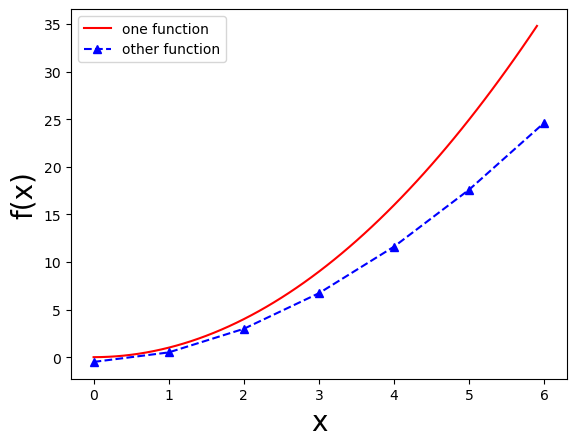

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

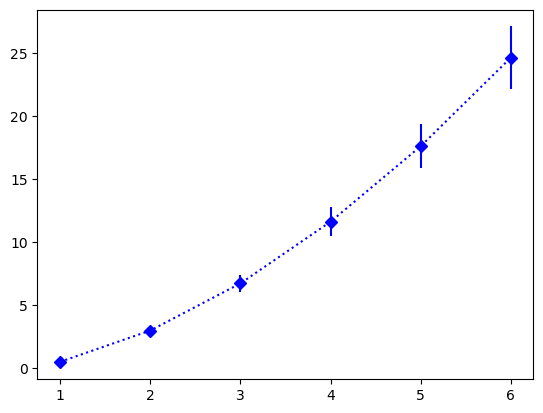

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])

<img src="figures/gezerlisTable1_3.png" width="67%">

<img src="figures/gezerlis_slicingArrays.png" width="67%">

### Visualizing Electric Fields 

The electric field anywhere given a set of $n$ point charges is given by
$$ \mathbf{E}(\mathbf{r}) = \sum_{i=0}^{n-1} kq_i \frac{\mathbf{r} - \mathbf{r}_i}{|\mathbf{r} - \mathbf{r}_i|^3} $$

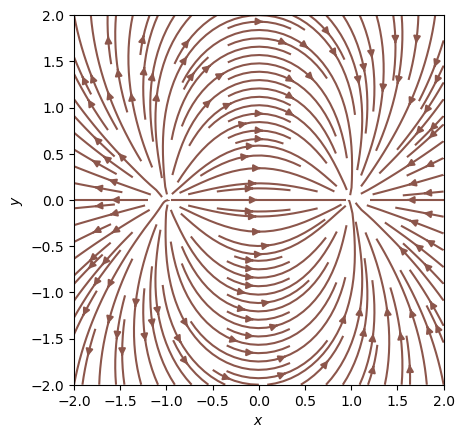

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from copy import deepcopy

def makefield(xs, ys):
    qtopos = {1: (-1,0), -1: (1,0)}
    n = len(xs)
    Exs = [[0. for k in range(n)] for j in range(n)]
    Eys = deepcopy(Exs)
    for j,x in enumerate(xs):
        for k,y in enumerate(ys):
            for q, pos in qtopos.items():
                posx, posy  = pos
                R = sqrt((x - posx)**2 + (y - posy)**2)
                Exs[k][j] += q*(x - posx)/R**3
                Eys[k][j] += q*(y - posy)/R**3
    return Exs, Eys

def plotfield(boxl,n):
    xs = [-boxl + i*2*boxl/(n-1) for i in range(n)]
    ys = xs[:]
    Exs, Eys = makefield(xs, ys)
    xs=np.array(xs); ys=np.array(ys)
    Exs=np.array(Exs); Eys=np.array(Eys)
    plt.streamplot(xs, ys, Exs, Eys, density=1.5, color='tab:brown')
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.axis('square')
    plt.show()
    
plotfield(2., 50)

In [48]:
# sample plotting in notebook and putting saved image in another cell (see Report figure)

import matplotlib.pyplot as plt
import numpy as np

# sample grid and data
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z1 = np.sin(np.sqrt(X**2 + Y**2))        

# create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# plot on first axs (left)
axs[0].imshow(Z1, cmap='viridis')
axs[0].set_title("Subtitle 1")
axs[0].axis('off')

# plot on the second axis (right)
axs[1].imshow(Z1, cmap='plasma')
axs[1].set_title("Subtitle 2")
axs[1].axis('off')

fig.suptitle("Super title")

# save image locally without rendering in the notebook
plt.savefig('figures/sample.png', bbox_inches='tight', dpi=150)
plt.close()